In [1]:
#Section 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import random
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.metrics import accuracy_score

In [2]:
import sys
sys.path.append(os.path.abspath(".."))

In [3]:
#Section 2 - Device Configuration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


In [5]:
from src.data_loader import *
from src.transforms import *
from src.models import *
from src.train import *
from src.evaluate import *
print("Data Loader Imported Successfully")

Data Loader Imported Successfully


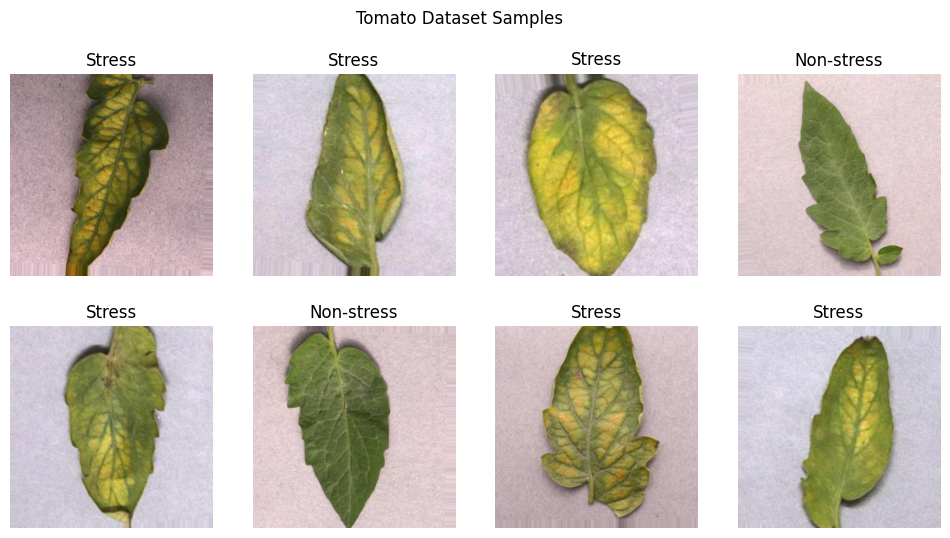

In [5]:
#Section 8 - View sample Images
label_names = {
    0: "Non-stress",
    1: "Stress"
}

random_indices = random.sample(range(len(tomato_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(tomato_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = tomato_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Tomato Dataset Samples")
plt.show()

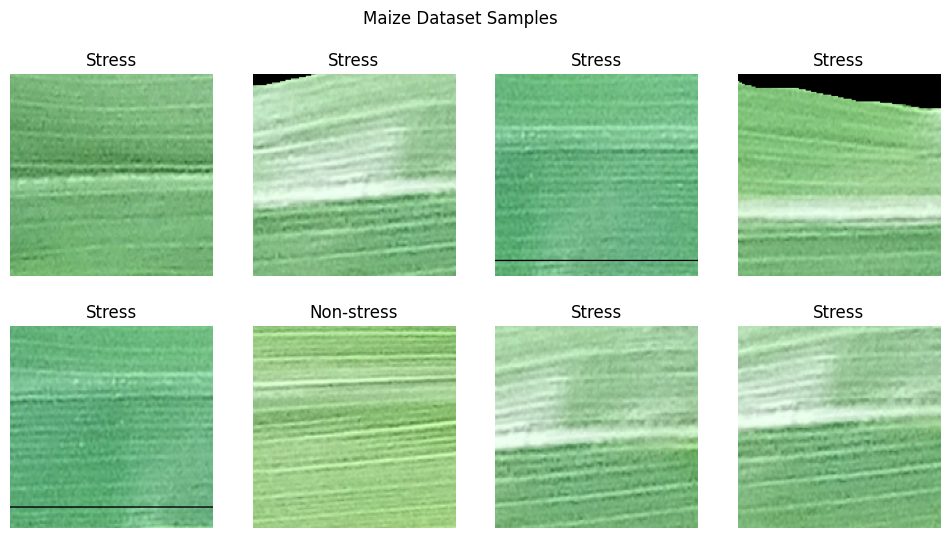

In [6]:
random_indices = random.sample(range(len(maize_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(maize_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = maize_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Maize Dataset Samples")
plt.show()

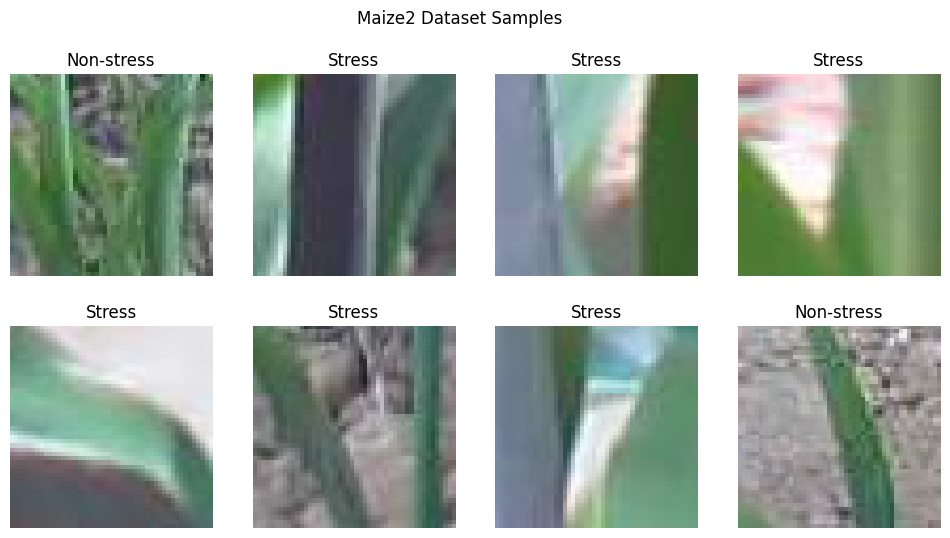

In [7]:
# Random sample indices
random_indices = random.sample(range(len(train_maize2_data)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    # Directly get image array
    image = train_maize2_data[idx]

    # Get label
    label = train_maize2_labels[idx]

    plt.subplot(2,4,i+1)

    # Display image
    plt.imshow(image.astype("uint8"))

    plt.title(label_names[label])

    plt.axis("off")

plt.suptitle("Maize2 Dataset Samples")

plt.show()

In [6]:
#Section 10 - Create Dataset and Dataloaders

tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, transform)

maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, transform)

maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, transform)


tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, transform)

maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, transform)

maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, transform)


tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, transform)

maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, transform)

maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, transform)

batch_size = 32

tomato_train_loader = DataLoader(
    tomato_train_dataset, batch_size=batch_size, shuffle=True)
tomato_val_loader = DataLoader(
    tomato_val_dataset, batch_size=batch_size, shuffle=False)
tomato_test_loader = DataLoader(
    tomato_test_dataset, batch_size=batch_size, shuffle=False)

maize_train_loader = DataLoader(
    maize_train_dataset, batch_size=batch_size, shuffle=True)
maize_val_loader = DataLoader(
    maize_val_dataset, batch_size=batch_size, shuffle=False)
maize_test_loader = DataLoader(
    maize_test_dataset, batch_size=batch_size, shuffle=False)

maize2_train_loader = DataLoader(
    maize2_train_dataset, batch_size=batch_size, shuffle=True)
maize2_val_loader = DataLoader(
    maize2_val_dataset, batch_size=batch_size, shuffle=False)
maize2_test_loader = DataLoader(
    maize2_test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
#Section 13 - Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()

# Tomato Optimizer
tomato_optimizer = torch.optim.Adam(
    tomato_model.parameters(),
    lr=0.0001
)

# Maize Optimizer
maize_optimizer = torch.optim.Adam(
    maize_model.parameters(),
    lr=0.0001
)

# Maize2 Optimizer
maize2_optimizer = torch.optim.Adam(
    maize2_model.parameters(),
    lr=0.0001
)

In [10]:
#Section 15 - Train baseline model

print("Training Tomato Model")

train_model(
    tomato_model,
    tomato_train_loader,
    tomato_val_loader,
    tomato_optimizer,
    criterion,
    device,
    epochs=5
)

print("Training Maize Model")

train_model(
    maize_model,
    maize_train_loader,
    maize_val_loader,
    maize_optimizer,
    criterion,
    device,
    epochs=5
)

print("Training Maize2 Model")

train_model(
    maize2_model,
    maize2_train_loader,
    maize2_val_loader,
    maize2_optimizer,
    criterion,
    device,
    epochs=5
)


Training Tomato Model
Epoch [1/5]
Train Loss: 0.0309
Validation Accuracy: 99.90%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0125
Validation Accuracy: 99.30%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0095
Validation Accuracy: 99.87%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0071
Validation Accuracy: 99.87%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0080
Validation Accuracy: 100.00%
----------------------------------------
Training Maize Model
Epoch [1/5]
Train Loss: 0.2564
Validation Accuracy: 25.00%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0168
Validation Accuracy: 63.33%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0422
Validation Accuracy: 90.00%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0342
Validation Accuracy: 100.00%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0247
Validation Accuracy: 100

([0.14021266536787153,
  0.09249016053974629,
  0.06709628442379957,
  0.061483322870529565,
  0.06269836871962374],
 [93.23590814196243,
  94.19624217118998,
  85.05219206680584,
  88.01670146137788,
  82.04592901878914])

In [13]:
os.makedirs("saved_models", exist_ok=True)

# Save trained model
torch.save(
    tomato_model.state_dict(),
    "saved_models/tomato_model.pth"
)

torch.save(
    maize_model.state_dict(),
    "saved_models/maize_model.pth"
)

torch.save(
    maize2_model.state_dict(),
    "saved_models/maize2_model.pth"
)


In [ ]:
# ============================================================
# SECTION 15 - LOAD SAVED MODELS
# ============================================================

tomato_model.load_state_dict(
    torch.load(
        "saved_models/tomato_model.pth",
        map_location=device
    )
)

maize_model.load_state_dict(
    torch.load(
        "saved_models/maize_model.pth",
        map_location=device
    )
)

maize2_model.load_state_dict(
    torch.load(
        "saved_models/maize2_model.pth",
        map_location=device
    )
)

# Set models to evaluation mode
tomato_model.eval()

maize_model.eval()

maize2_model.eval()

print("All saved models loaded successfully")

In [14]:
# ============================================================
# SECTION 17 - TEST INDIVIDUAL MODELS
# ============================================================

print("Tomato Model Performance")

tomato_acc = evaluate_model(
    tomato_model,
    tomato_test_loader,
    device
)

print("Maize Model Performance")

maize_acc = evaluate_model(
    maize_model,
    maize_test_loader,
    device
)


print("Maize2 Model Performance")

maize2_acc = evaluate_model(
    maize2_model,
    maize2_test_loader,
    device
)

Tomato Model Performance
Test Accuracy: 99.94%
Maize Model Performance
Test Accuracy: 100.00%
Maize2 Model Performance
Test Accuracy: 82.46%


In [16]:
#Section 19 - Test Ensemble Model

sample_image, sample_label = tomato_test_dataset[0]

prediction = ensemble_predict(
    sample_image,
    tomato_model,
    maize_model,
    maize2_model,
    device
)

print("Actual Label:", sample_label)
print("Predicted Label:", prediction)

Actual Label: 1
Predicted Label: 1


In [17]:
#Section 20 - Merge all test datasets for ensemble evaluation

# Combine all test images
merged_test_data = (
    test_tomato_data +
    test_maize_data +
    list(test_maize2_data)
)

# Combine all test labels

merged_test_labels = (
    list(test_tomato_labels) +
    list(test_maize_labels) +
    list(test_maize2_labels)
)

print("Total Test Images:", len(merged_test_data))
print("Total Test Labels:", len(merged_test_labels))

Total Test Images: 9269
Total Test Labels: 9269


In [18]:
merged_test_dataset = LeafDataset(
    merged_test_data,
    merged_test_labels,
    transform
)

In [21]:
ensemble_acc = evaluate_ensemble(
    merged_test_dataset,
    tomato_model,
    maize_model,
    maize2_model,
    device
)

Ensemble Accuracy: 77.33%


# Version 2 - Fine-tunned Ensemble Model 

In [22]:
#Section2 - Create Improved Datasets

improved_tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, improved_transform
)
improved_tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, improved_transform
)
improved_tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, improved_transform
)

improved_maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, improved_transform
)   
improved_maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, improved_transform
)
improved_maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, improved_transform
)

improved_maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, improved_transform
)
improved_maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, improved_transform
)
improved_maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, improved_transform
)

In [23]:
#Section 3 - Improved Dataloaders

improved_tomato_train_loader = DataLoader(
    improved_tomato_train_dataset, batch_size=32, shuffle=True
)
improved_tomato_val_loader = DataLoader(
    improved_tomato_val_dataset, batch_size=32, shuffle=False
)
improved_tomato_test_loader = DataLoader(
    improved_tomato_test_dataset, batch_size=32, shuffle=False
)

improved_maize_train_loader = DataLoader(
    improved_maize_train_dataset, batch_size=32, shuffle=True
)
improved_maize_val_loader = DataLoader(
    improved_maize_val_dataset, batch_size=32, shuffle=False
)
improved_maize_test_loader = DataLoader(
    improved_maize_test_dataset, batch_size=32, shuffle=False
)

improved_maize2_train_loader = DataLoader(
    improved_maize2_train_dataset, batch_size=32, shuffle=True
)
improved_maize2_val_loader = DataLoader(
    improved_maize2_val_dataset, batch_size=32, shuffle=False
)
improved_maize2_test_loader = DataLoader(
    improved_maize2_test_dataset, batch_size=32, shuffle=False
)

In [24]:
#Section 5  - Improved Optimizers

improved_tomato_optimizer = torch.optim.Adam(
    improved_tomato_model.parameters(),
    lr=0.0001
)

improved_maize_optimizer = torch.optim.Adam(
    improved_maize_model.parameters(),
    lr=0.0001
)

improved_maize2_optimizer = torch.optim.Adam(
    improved_maize2_model.parameters(),
    lr=0.0001
)

In [26]:
# ============================================================
# SECTION 6 - TRAIN IMPROVED MODELS
# ============================================================

print("Training Improved Tomato Model")

train_model(
    improved_tomato_model,
    improved_tomato_train_loader,
    improved_tomato_val_loader,
    improved_tomato_optimizer,
    criterion,
    device,
    epochs=15
)


print("Training Improved Maize Model")

train_model(
    improved_maize_model,
    improved_maize_train_loader,
    improved_maize_val_loader,
    improved_maize_optimizer,
    criterion,
    device,
    epochs=15
)


print("Training Improved Maize2 Model")

train_model(
    improved_maize2_model,
    improved_maize2_train_loader,
    improved_maize2_val_loader,
    improved_maize2_optimizer,
    criterion,
    device,
    epochs=15
)

Training Improved Tomato Model
Epoch [1/15]
Train Loss: 0.0583
Validation Accuracy: 99.71%
----------------------------------------
Epoch [2/15]
Train Loss: 0.0060
Validation Accuracy: 100.00%
----------------------------------------
Epoch [3/15]
Train Loss: 0.0029
Validation Accuracy: 100.00%
----------------------------------------
Epoch [4/15]
Train Loss: 0.0020
Validation Accuracy: 99.97%
----------------------------------------
Epoch [5/15]
Train Loss: 0.0013
Validation Accuracy: 100.00%
----------------------------------------
Epoch [6/15]
Train Loss: 0.0019
Validation Accuracy: 100.00%
----------------------------------------
Epoch [7/15]
Train Loss: 0.0019
Validation Accuracy: 100.00%
----------------------------------------
Epoch [8/15]
Train Loss: 0.0011
Validation Accuracy: 100.00%
----------------------------------------
Epoch [9/15]
Train Loss: 0.0002
Validation Accuracy: 100.00%
----------------------------------------
Epoch [10/15]
Train Loss: 0.0000
Validation Accuracy:

([0.19802063884834448,
  0.11650004893541337,
  0.08845836388257643,
  0.07752380201593041,
  0.07144107093724111,
  0.06123856952957188,
  0.05293743410535778,
  0.04884368475099715,
  0.038356164833530784,
  0.035420683779132864,
  0.03325404302372287,
  0.024242995419966367,
  0.027260942657012493,
  0.026867600696132286,
  0.025213491840695497],
 [93.1106471816284,
  93.73695198329854,
  92.52609603340292,
  91.89979123173278,
  91.89979123173278,
  92.06680584551148,
  93.52818371607516,
  92.23382045929019,
  93.9874739039666,
  89.85386221294364,
  92.94363256784969,
  94.02922755741128,
  90.81419624217119,
  94.78079331941545,
  90.93945720250522])

In [27]:
# Save Improved Tomato Model
torch.save(
    improved_tomato_model.state_dict(),
    "saved_models/improved_tomato_model.pth"
)

# Save Improved Maize Model
torch.save(
    improved_maize_model.state_dict(),
    "saved_models/improved_maize_model.pth"
)

# Save Improved Maize2 Model
torch.save(
    improved_maize2_model.state_dict(),
    "saved_models/improved_maize2_model.pth"
)

print("All Improved Models Saved Successfully")

All Improved Models Saved Successfully


In [28]:
# ============================================================
# SECTION 6 - LOAD IMPROVED MODELS
# ============================================================

improved_tomato_model.load_state_dict(
    torch.load(
        "saved_models/improved_tomato_model.pth",
        map_location=device
    )
)

improved_maize_model.load_state_dict(
    torch.load(
        "saved_models/improved_maize_model.pth",
        map_location=device
    )
)

improved_maize2_model.load_state_dict(
    torch.load(
        "saved_models/improved_maize2_model.pth",
        map_location=device
    )
)

# Set evaluation mode
improved_tomato_model.eval()

improved_maize_model.eval()

improved_maize2_model.eval()

print("All Improved Models Loaded Successfully")

All Improved Models Loaded Successfully


In [30]:
improved_ensemble_acc = evaluate_improved_ensemble(
    merged_test_dataset,
    improved_tomato_model,
    improved_maize_model,
    improved_maize2_model,
    device
)

Improved Ensemble Accuracy: 75.75%
